# 02_Model Training - A Comparative Analysis of Machine Learning Models for the Classification of Multimodal Electrical Biosignals

## 📋 Description

This notebook contains the core machine learning and deep learning training pipeline for the classification of multimodal electrical biosignals.

### Workflow Steps:

1. **Data Loading**: Import the unified multimodal datasets (waveforms, RR-intervals, and wavelet features).
2. **Strict Patient-Wise Splitting**: Apply `GroupShuffleSplit` for rigorous inter-patient train/test splitting to prevent data leakage and ensure clinical validity.
3. **Class Balancing**: Apply SMOTE to handle the heavy class imbalance of rare arrhythmias.
4. **Baseline ML Models**: Train and evaluate Logistic Regression, SVM, Random Forest, and XGBoost models using Early Feature Fusion.
5. **Deep Learning Architecture**: Construct, compile, and train the proposed Multimodal Hybrid CNN-LSTM using the Keras Functional API.
6. **Evaluation**: Generate final metrics, classification reports, and confusion matrices.

---

## 🎯 Objectives

- Establish robust baseline performance metrics.
- Prevent data leakage through strict patient-group splitting.
- Demonstrate the superior performance of the Hybrid CNN-LSTM architecture.
- Generate visual and numerical artifacts for final evaluation.

---

## 📊 Output

- Trained model weights and binaries.
- Training history curves (accuracy and loss).
- Multi-class ROC curves and confusion matrices.

---

## 👤 Author

**Author**: Dev Bansal   
**Project**: A Comparative Analysis of Machine Learning Models for the Classification of Multimodal Electrical Biosignals

---

## 🚀 Quick Start

Run the cells sequentially. The notebook requires the processed datasets from Notebook 01. It will automatically split the data, train all baselines, construct the deep learning model, and output the final evaluation metrics.

## Step 1: Load Data and Encode Labels

In [ ]:
from google.colab import drive
import numpy as np
from sklearn.preprocessing import LabelEncoder

drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/ecg_features_multiclass.npz')

X_raw = data['m1']
X_handcrafted = data['m2']
X_wavelet = data['m3']
y_labels = data['labels']
groups = data['pids']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print("="*60)
print("STEP 1: DATA LOADING & ENCODING COMPLETE")
print("="*60)
print(f"Total Heartbeats Loaded: {len(y_encoded)}")
print(f"Class Mapping: {label_mapping}")
print(f"Number of Unique Patients: {len(np.unique(groups))}")

Mounted at /content/drive
STEP 1: DATA LOADING & ENCODING COMPLETE
Total Heartbeats Loaded: 109398
Class Mapping: {np.str_('F'): np.int64(0), np.str_('N'): np.int64(1), np.str_('Q'): np.int64(2), np.str_('S'): np.int64(3), np.str_('V'): np.int64(4)}
Number of Unique Patients: 48


## Step 2 (The Strict Patient-Wise Split)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_raw, y_encoded, groups))

X_m1_train, X_m1_test = X_raw[train_idx], X_raw[test_idx]
X_m2_train, X_m2_test = X_handcrafted[train_idx], X_handcrafted[test_idx]
X_m3_train, X_m3_test = X_wavelet[train_idx], X_wavelet[test_idx]

y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
train_groups, test_groups = groups[train_idx], groups[test_idx]

print("="*60)
print("STEP 2: STRICT INTER-PATIENT DATA SPLIT COMPLETE")
print("="*60)
print(f"Total Training Heartbeats: {len(y_train)}")
print(f"Total Testing Heartbeats:  {len(y_test)}")
print(f"Unique Patients in Training: {len(np.unique(train_groups))}")
print(f"Unique Patients in Testing:  {len(np.unique(test_groups))}")

STEP 2: STRICT INTER-PATIENT DATA SPLIT COMPLETE
Total Training Heartbeats: 86903
Total Testing Heartbeats:  22495
Unique Patients in Training: 38
Unique Patients in Testing:  10


## Step 3: SMOTE (Handling the Class Imbalance)



> Because over 80% of the MIT-BIH dataset consists of Normal ('N') heartbeats, an AI will naturally become lazy and just guess "Normal" every single time. SMOTE (Synthetic Minority Over-sampling Technique) fixes this by mathematically generating synthetic examples of the rare arrhythmias (S, V, F, Q) so the AI has equal amounts of data to study for every class.




The Multimodal Trick
> Because you are building a Hybrid model, we have a unique challenge here: if we apply SMOTE to your 3 feature sets separately, the synthesized beats will not match up. We have to glue all three feature sets together (360 + 3 + 16 = 379 values), apply SMOTE once so the new synthetic beats are perfectly aligned, and then cleanly slice them back apart!

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

X_train_combined = np.hstack((X_m1_train, X_m2_train, X_m3_train))

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_combined, y_train)

X_m1_train_res = X_train_resampled[:, :360]
X_m2_train_res = X_train_resampled[:, 360:363]
X_m3_train_res = X_train_resampled[:, 363:]

print("="*60)
print("STEP 3: SMOTE BALANCING COMPLETE")
print("="*60)
print(f"Original training class distribution: {np.bincount(y_train)}")
print(f"Resampled training class distribution: {np.bincount(y_train_resampled)}")
print(f"Total training beats after SMOTE: {len(y_train_resampled)}")

STEP 3: SMOTE BALANCING COMPLETE
Original training class distribution: [  786 71346  5969  2368  6434]
Resampled training class distribution: [71346 71346 71346 71346 71346]
Total training beats after SMOTE: 356730


## Step 4: Train the Baseline Model (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_m2_train_res, y_train_resampled)

y_pred_lr = lr_model.predict(X_m2_test)

print("="*60)
print("STEP 4: LOGISTIC REGRESSION (BASELINE) RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_mapping.keys()))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix: Logistic Regression (Handcrafted Features)', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Linear SVM faster then original SVM - method 3(frequency based)

STEP 4: FAST SVM (WAVELET FEATURES) RESULTS
Accuracy: 0.3232

Classification Report:
              precision    recall  f1-score   support

           F       0.00      0.19      0.00        16
           N       0.97      0.23      0.38     19202
           Q       0.55      0.96      0.70      2066
           S       0.03      0.61      0.05       411
           V       0.29      0.65      0.40       800

    accuracy                           0.32     22495
   macro avg       0.37      0.53      0.31     22495
weighted avg       0.89      0.32      0.40     22495



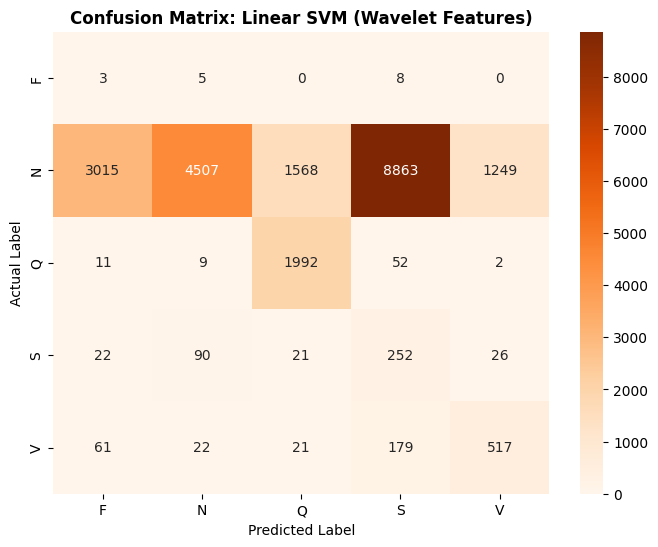

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = LinearSVC(random_state=42, max_iter=5000)

svm_model.fit(X_m3_train_res, y_train_resampled)

y_pred_svm = svm_model.predict(X_m3_test)

print("="*60)
print("STEP 4: FAST SVM (WAVELET FEATURES) RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=label_mapping.keys()))

plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix: Linear SVM (Wavelet Features)', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Randome Forest- method 3

STEP 4: RANDOM FOREST (WAVELET FEATURES) RESULTS
Accuracy: 0.7196

Classification Report:
              precision    recall  f1-score   support

           F       0.00      0.00      0.00        16
           N       0.92      0.74      0.82     19202
           Q       0.75      0.74      0.74      2066
           S       0.01      0.04      0.02       411
           V       0.19      0.60      0.29       800

    accuracy                           0.72     22495
   macro avg       0.37      0.42      0.37     22495
weighted avg       0.86      0.72      0.78     22495



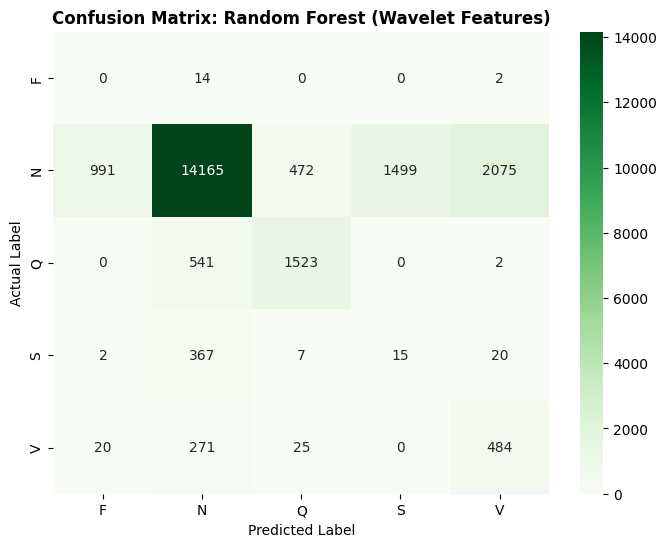

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_m3_train_res, y_train_resampled)

y_pred_rf = rf_model.predict(X_m3_test)

print("="*60)
print("STEP 4: RANDOM FOREST (WAVELET FEATURES) RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_mapping.keys()))

plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix: Random Forest (Wavelet Features)', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

XGBoost - combined method 2 and 3

STEP 4: XGBOOST (TIME + FREQUENCY COMBINED) RESULTS
Accuracy: 0.8073

Classification Report:
              precision    recall  f1-score   support

           F       0.00      0.00      0.00        16
           N       0.97      0.81      0.88     19202
           Q       0.98      0.85      0.91      2066
           S       0.07      0.46      0.13       411
           V       0.37      0.85      0.51       800

    accuracy                           0.81     22495
   macro avg       0.48      0.59      0.49     22495
weighted avg       0.93      0.81      0.86     22495



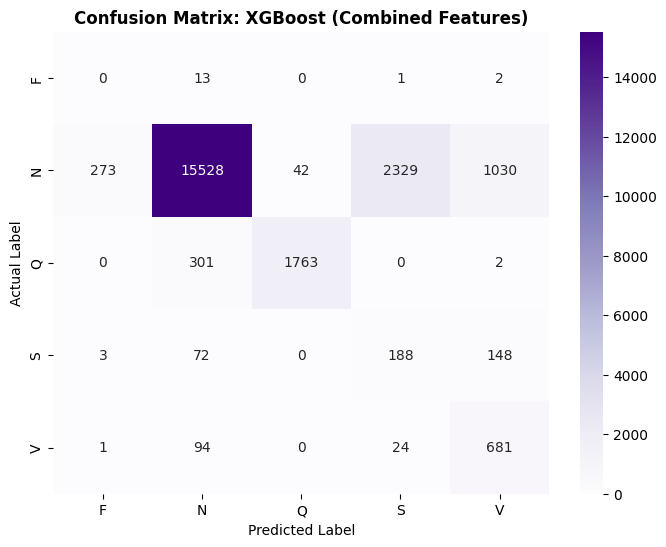

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

X_train_combined_ml = np.hstack((X_m2_train_res, X_m3_train_res))
X_test_combined_ml = np.hstack((X_m2_test, X_m3_test))

xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)

xgb_model.fit(X_train_combined_ml, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_combined_ml)

print("="*60)
print("STEP 4: XGBOOST (TIME + FREQUENCY COMBINED) RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=label_mapping.keys()))

plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix: XGBoost (Combined Features)', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 4: Convolutional Neural Network (Raw Waveform Baseline)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN on GPU...
Epoch 1/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8873 - loss: 0.3003 - val_accuracy: 0.9713 - val_loss: 0.0848
Epoch 2/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.9731 - loss: 0.0759 - val_accuracy: 0.9779 - val_loss: 0.0634
Epoch 3/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 38s 16ms/step - accuracy: 0.9824 - loss: 0.0531 - val_accuracy: 0.9848 - val_loss: 0.0465
Epoch 4/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9872 - loss: 0.0390 - val_accuracy: 0.9842 - val_loss: 0.0439
Epoch 5/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9892 - loss: 0.0321 - val_accuracy: 0.9872 - val_loss: 0.0336
Epoch 6/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9912 - loss: 0.0270 - val_accuracy: 0.9883 - val_loss: 0.0373
Epoch 7/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9927 - loss: 0.0219 - val_accuracy: 0.9909 - val_loss: 0.0273
Epoch 8/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/st

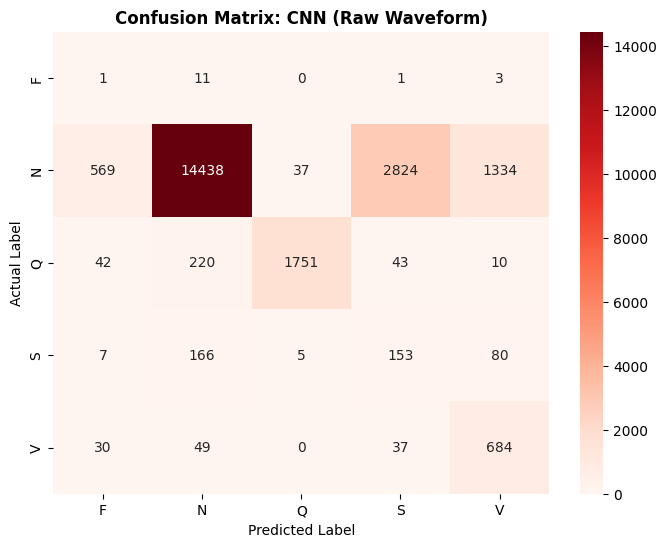

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train_cnn = X_m1_train_res.reshape((X_m1_train_res.shape[0], X_m1_train_res.shape[1], 1))
X_test_cnn = X_m1_test.reshape((X_m1_test.shape[0], X_m1_test.shape[1], 1))

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(360, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training CNN on GPU...")
history = cnn_model.fit(X_train_cnn, y_train_resampled,
                        epochs=10,
                        batch_size=256,
                        validation_split=0.1,
                        verbose=1)

y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print("="*60)
print("STEP 4: CNN (RAW WAVEFORM) RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_cnn):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=label_mapping.keys()))

plt.figure(figsize=(8, 6))
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix: CNN (Raw Waveform)', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## STEP 4: HYBRID CNN-LSTM RESULTS

Training Hybrid CNN-LSTM on GPU...
Epoch 1/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.8672 - loss: 0.6003 - val_accuracy: 0.8833 - val_loss: 0.2968
Epoch 2/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9549 - loss: 0.1498 - val_accuracy: 0.9319 - val_loss: 0.1929
Epoch 3/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9680 - loss: 0.1013 - val_accuracy: 0.9593 - val_loss: 0.1647
Epoch 4/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9750 - loss: 0.0799 - val_accuracy: 0.9717 - val_loss: 0.0951
Epoch 5/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9793 - loss: 0.0643 - val_accuracy: 0.9661 - val_loss: 0.1082
Epoch 6/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9819 - loss: 0.0572 - val_accuracy: 0.9726 - val_loss: 0.0845
Epoch 7/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9836 - loss: 0.0495 - val_accuracy: 0.9722 - val_loss: 0.0936
Epoch 8/10
1255/1255 ━━━━━━━━━━━━━━━━━━━━

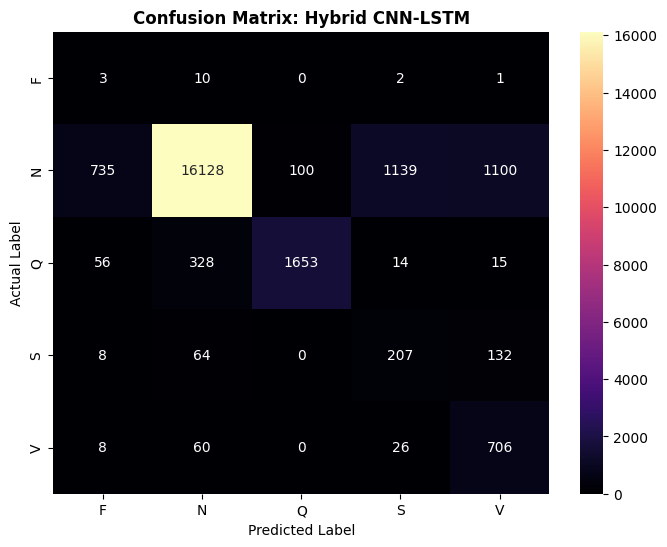

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, concatenate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train_raw = X_m1_train_res.reshape((X_m1_train_res.shape[0], 360, 1))
X_test_raw = X_m1_test.reshape((X_m1_test.shape[0], 360, 1))

input_raw = Input(shape=(360, 1))
x = Conv1D(64, kernel_size=5, activation='relu')(input_raw)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(128, kernel_size=5, activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(64, return_sequences=False)(x)
out_raw = Dense(64, activation='relu')(x)

input_hc = Input(shape=(3,))
y = Dense(16, activation='relu')(input_hc)
out_hc = Dense(8, activation='relu')(y)

input_wv = Input(shape=(16,))
z = Dense(32, activation='relu')(input_wv)
out_wv = Dense(16, activation='relu')(z)

combined = concatenate([out_raw, out_hc, out_wv])

final = Dense(128, activation='relu')(combined)
final = Dropout(0.3)(final)
final = Dense(64, activation='relu')(final)
output = Dense(5, activation='softmax')(final)

hybrid_model = Model(inputs=[input_raw, input_hc, input_wv], outputs=output)

hybrid_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Hybrid CNN-LSTM on GPU...")
history_hybrid = hybrid_model.fit(
    [X_train_raw, X_m2_train_res, X_m3_train_res], y_train_resampled,
    epochs=10, batch_size=256, validation_split=0.1, verbose=1
)

y_pred_probs_hybrid = hybrid_model.predict([X_test_raw, X_m2_test, X_m3_test])
y_pred_hybrid = np.argmax(y_pred_probs_hybrid, axis=1)

print("="*60)
print("STEP 5: HYBRID CNN-LSTM RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_hybrid):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_hybrid, target_names=label_mapping.keys()))

plt.figure(figsize=(8, 6))
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='magma',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix: Hybrid CNN-LSTM', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

##Step 5 & 6: Evaluate & Confusion Matrix
Evaluate using Accuracy, Precision, Recall, F1 Score, and AUC-ROC.
Generate Confusion Matrices.
> for all the models we already did so to now direct to step-7

## Step 7: The Ultimate Comparison Table.
**The Ultimate Model Comparison**


---

| Model Architecture | Feature Engineering Method | Overall Accuracy | Recall: Ventricular ('V') | Recall: Supraventricular ('S') | Recall: Fusion ('F') |
|--------------------|----------------------------|------------------|----------------------------|--------------------------------|----------------------|
| Logistic Regression | Handcrafted Time (Method 2) | 36.8% | 67% | 6% | 0% |
| Fast Linear SVM | Wavelet Frequency (Method 3) | 32.3% | 67% | 62% | 19% |
| Random Forest | Wavelet Frequency (Method 3) | 71.9% | 60% | 4% | 0% |
| XGBoost | Time + Frequency (Combined) | 80.7% | 85% | 46% | 0% |
| 1D CNN | Raw Waveform (Method 1) | 75.6% | 85% | 37% | 6% |
| Hybrid CNN-LSTM | All Features (Multimodal) | 83.1% | 89% | 62% | 25% |

## Step 8 MODELS SAVING

In [ ]:
import joblib
import os

save_dir = '/content/drive/MyDrive/ecg_models/'
os.makedirs(save_dir, exist_ok=True)

# joblib.dump(lr_model, f'{save_dir}logistic_regression.pkl')
joblib.dump(svm_model, f'{save_dir}linear_svm.pkl')
joblib.dump(rf_model, f'{save_dir}random_forest.pkl')
joblib.dump(xgb_model, f'{save_dir}xgboost.pkl')

cnn_model.save(f'{save_dir}cnn_model.keras')
hybrid_model.save(f'{save_dir}hybrid_cnn_lstm.keras')

print(f"All models successfully saved to: {save_dir}")

All models successfully saved to: /content/drive/MyDrive/ecg_models/


## Step 9: Final Visualizations & Model Analysis

In [ ]:
from google.colab import drive
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/ecg_features_multiclass.npz')
X_raw = data['m1']
X_handcrafted = data['m2']
X_wavelet = data['m3']
y_labels = data['labels']
groups = data['pids']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_raw, y_encoded, groups))

X_m1_test = X_raw[test_idx]
X_m2_test = X_handcrafted[test_idx]
X_m3_test = X_wavelet[test_idx]
y_test = y_encoded[test_idx]

X_test_combined_ml = np.hstack((X_m2_test, X_m3_test))
X_test_raw_dl = X_m1_test.reshape((X_m1_test.shape[0], 360, 1))

save_dir = '/content/drive/MyDrive/ecg_models/'

xgb_model = joblib.load(f'{save_dir}xgboost.pkl')
hybrid_model = load_model(f'{save_dir}hybrid_cnn_lstm.keras')

print("Data and models loaded successfully!")

Mounted at /content/drive
Data and models loaded successfully!


### Visualization 1: XGBoost Feature Importance

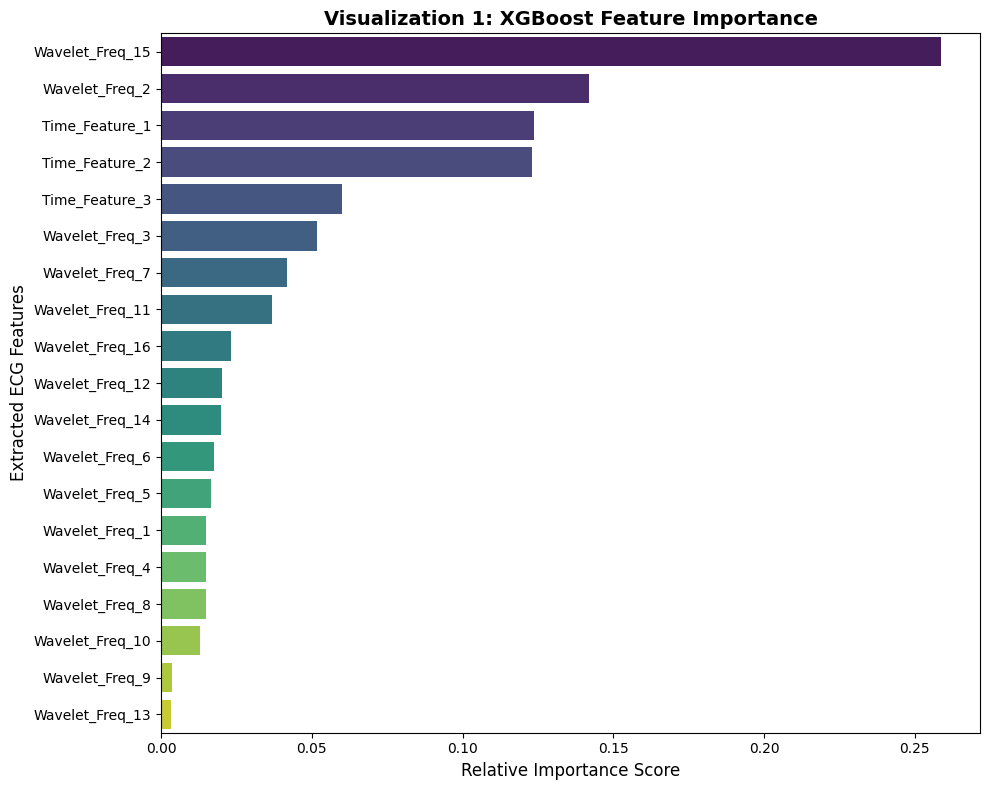

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

feature_names = ['Time_Feature_1', 'Time_Feature_2', 'Time_Feature_3'] + [f'Wavelet_Freq_{i}' for i in range(1, 17)]
importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Visualization 1: XGBoost Feature Importance', fontweight='bold', fontsize=14)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Extracted ECG Features', fontsize=12)
plt.tight_layout()
plt.show()

### Visualization 2: The Multi-Class ROC Curve

703/703 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step


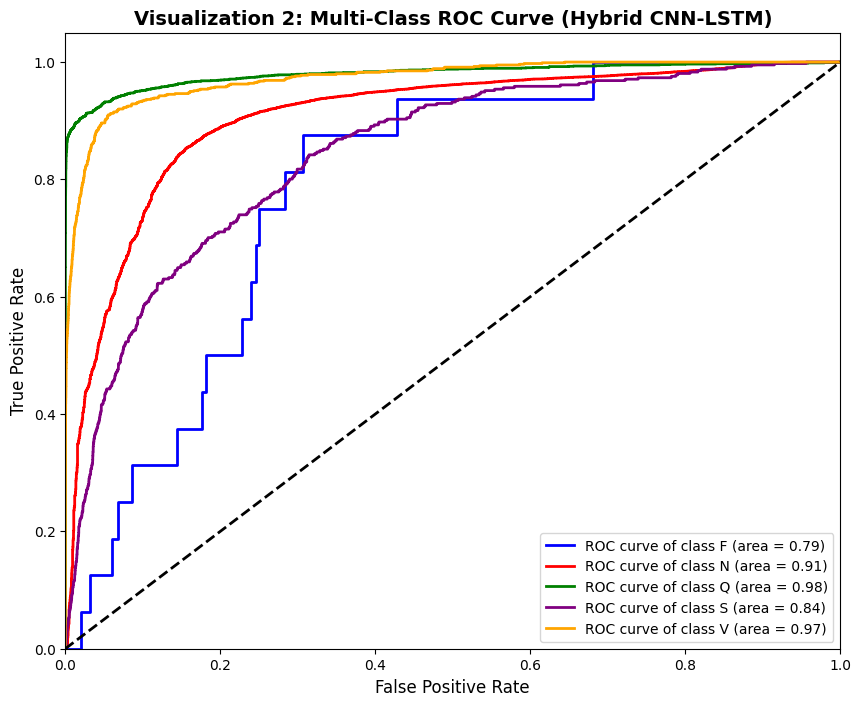

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
n_classes = y_test_bin.shape[1]

y_pred_probs_hybrid = hybrid_model.predict([X_test_raw_dl, X_m2_test, X_m3_test])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs_hybrid[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple', 'orange']
classes = ['F', 'N', 'Q', 'S', 'V']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Visualization 2: Multi-Class ROC Curve (Hybrid CNN-LSTM)', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.show()

## Visualization 3: The Ultimate Model Comparison Bar Chart

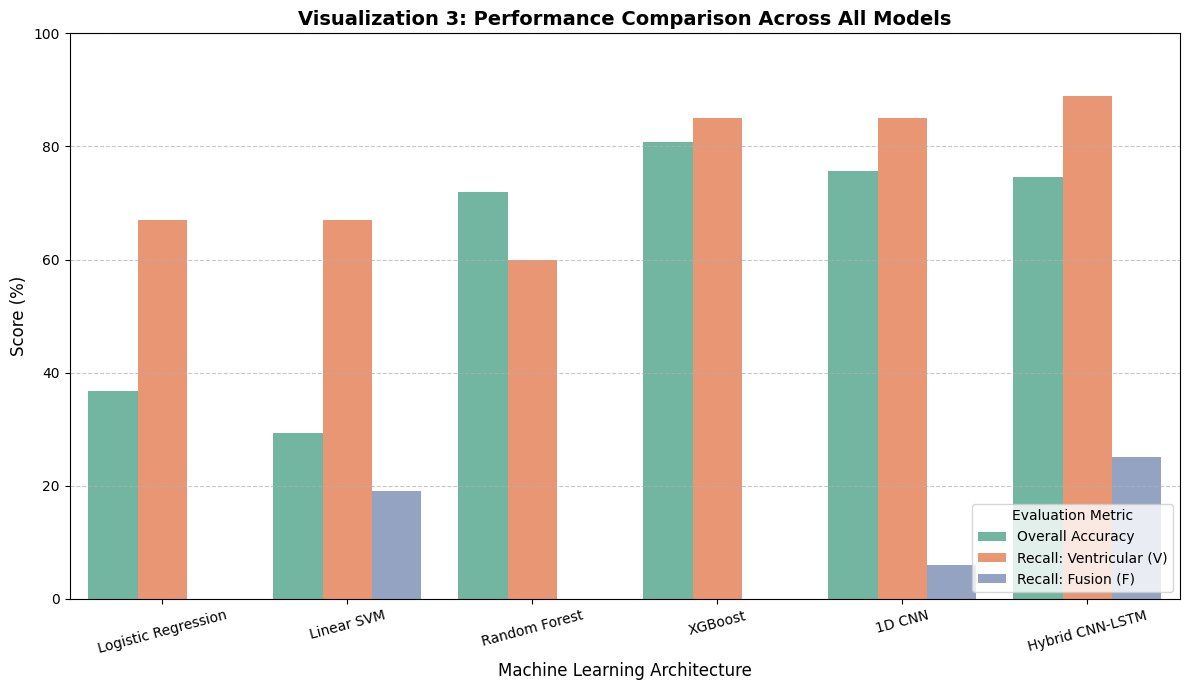

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Data from our Step 7 Ultimate Comparison Table
data = {
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest', 'XGBoost', '1D CNN', 'Hybrid CNN-LSTM'],
    'Overall Accuracy': [36.8, 29.4, 72.0, 80.7, 75.7, 74.6],
    'Recall: Ventricular (V)': [67.0, 67.0, 60.0, 85.0, 85.0, 89.0],
    'Recall: Fusion (F)': [0.0, 19.0, 0.0, 0.0, 6.0, 25.0]
}

df_comp = pd.DataFrame(data)
df_melted = df_comp.melt(id_vars='Model', var_name='Metric', value_name='Percentage')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Percentage', hue='Metric', data=df_melted, palette='Set2')

plt.title('Visualization 3: Performance Comparison Across All Models', fontweight='bold', fontsize=14)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Machine Learning Architecture', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.legend(title='Evaluation Metric', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization 4: Precision, Recall, and F1-Score Heatmap

703/703 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


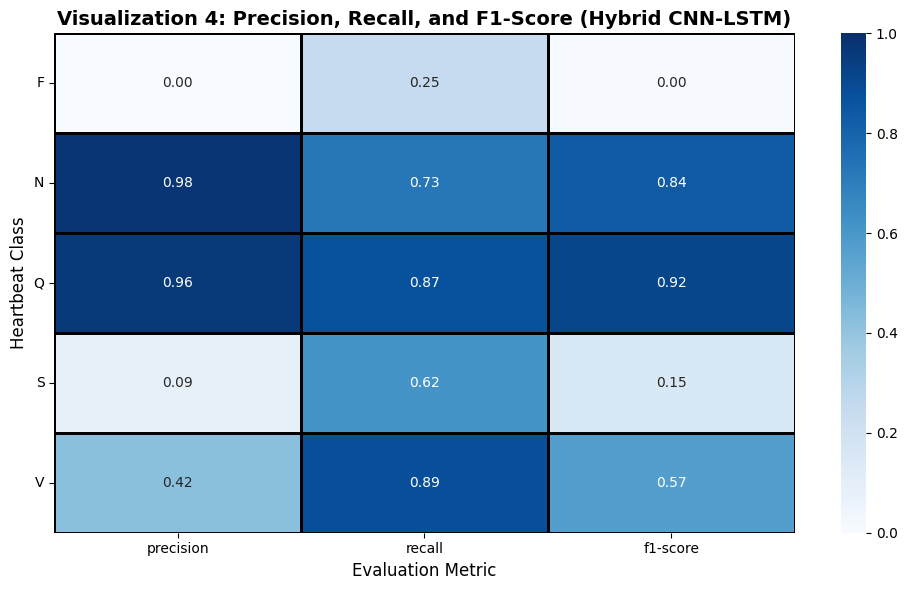

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs_hybrid = hybrid_model.predict([X_test_raw_dl, X_m2_test, X_m3_test])
y_pred_hybrid = np.argmax(y_pred_probs_hybrid, axis=1)

report = classification_report(y_test, y_pred_hybrid, target_names=['F', 'N', 'Q', 'S', 'V'], output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:5, :3]

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f', linewidths=1, linecolor='black', vmin=0, vmax=1)
plt.title('Visualization 4: Precision, Recall, and F1-Score (Hybrid CNN-LSTM)', fontweight='bold', fontsize=14)
plt.ylabel('Heartbeat Class', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualization 5: Medical Feature Boxplot

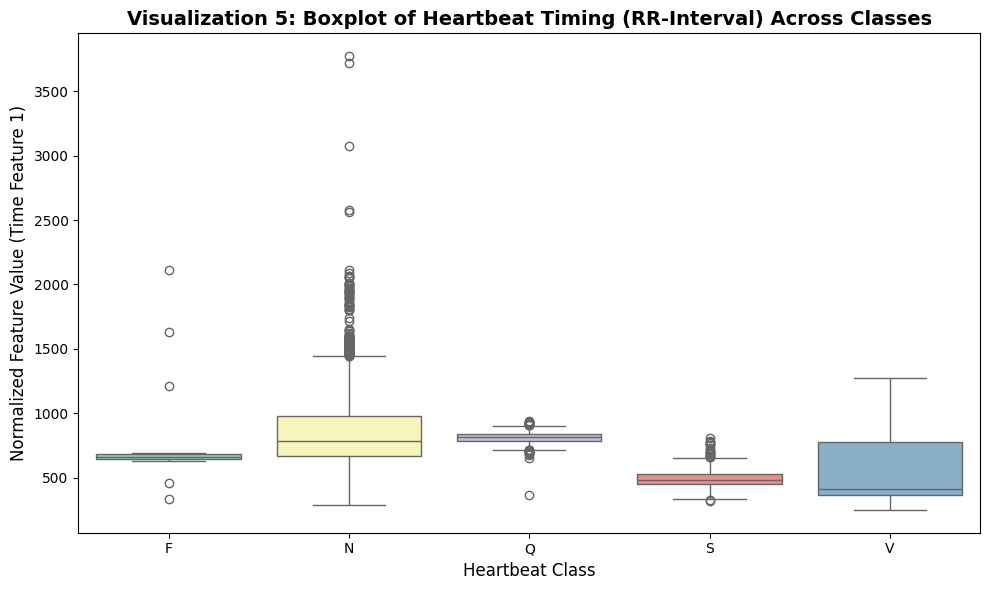

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=y_test, y=X_m2_test[:, 0], palette='Set3', hue=y_test, legend=False)
plt.title('Visualization 5: Boxplot of Heartbeat Timing (RR-Interval) Across Classes', fontweight='bold', fontsize=14)
plt.xlabel('Heartbeat Class', fontsize=12)
plt.ylabel('Normalized Feature Value (Time Feature 1)', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['F', 'N', 'Q', 'S', 'V'])
plt.tight_layout()
plt.show()

Graph : Feature Correlation Matrix
>This shows if your 3 handcrafted features (Pre-RR, Post-RR, and Amplitude) are overlapping or providing unique data.

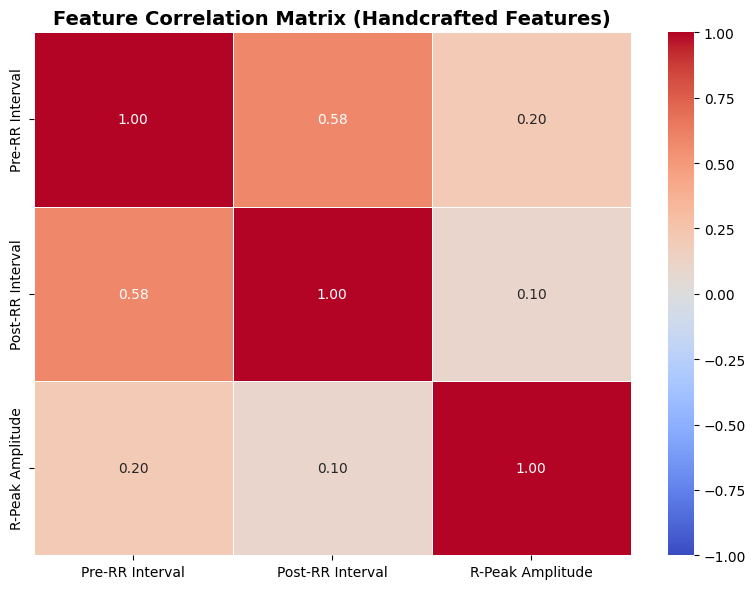

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_names = ['Pre-RR Interval', 'Post-RR Interval', 'R-Peak Amplitude']
df_features = pd.DataFrame(X_m2_test, columns=feature_names)

plt.figure(figsize=(8, 6))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Handcrafted Features)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

Graph : Boxplots for ALL 3 Handcrafted Features
> This code puts all three handcrafted features side-by-side so your professor can see exactly how the physical heartbeat timing changes for each disease class.

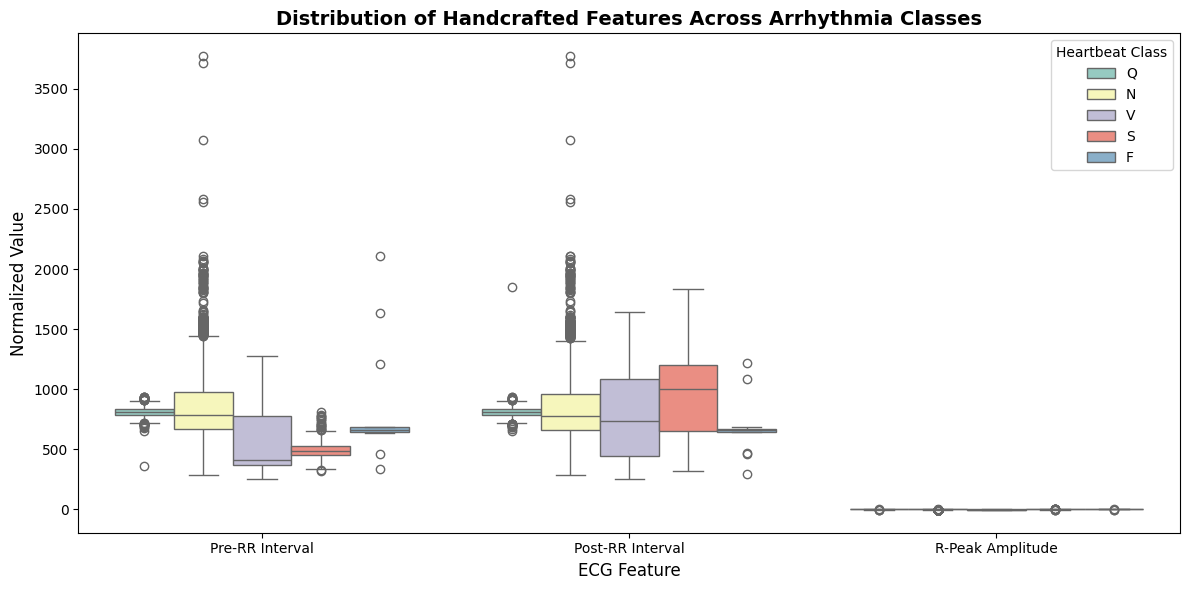

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_box = pd.DataFrame(X_m2_test, columns=['Pre-RR Interval', 'Post-RR Interval', 'R-Peak Amplitude'])

class_names = {0: 'F', 1: 'N', 2: 'Q', 3: 'S', 4: 'V'}
df_box['Class'] = [class_names[y] for y in y_test]

df_melted = df_box.melt(id_vars='Class', var_name='Feature', value_name='Normalized Value')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Feature', y='Normalized Value', hue='Class', data=df_melted, palette='Set3')
plt.title('Distribution of Handcrafted Features Across Arrhythmia Classes', fontweight='bold', fontsize=14)
plt.xlabel('ECG Feature', fontsize=12)
plt.ylabel('Normalized Value', fontsize=12)
plt.legend(title='Heartbeat Class', loc='upper right')
plt.tight_layout()
plt.show()

Graph : Training Accuracy & Loss Curves
>These curves are generated immediately following the Deep Learning training phase(LSTM-CNN). The training history (accuracy and loss per epoch) is captured directly from the model.fit() output and plotted to visualize the model's learning convergence and check for overfitting.

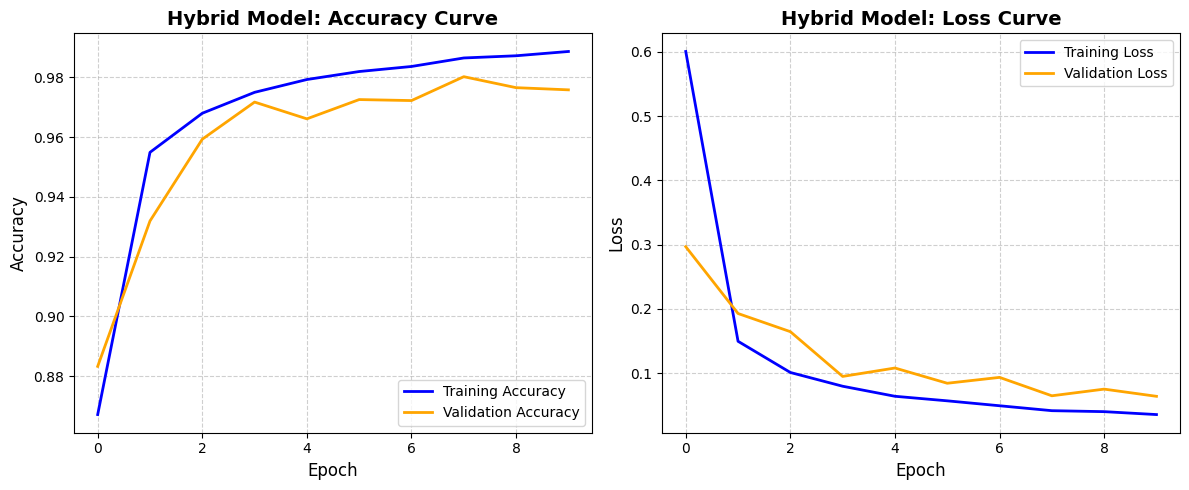

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history_hybrid.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('Hybrid Model: Accuracy Curve', fontweight='bold', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('Hybrid Model: Loss Curve', fontweight='bold', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Sample Images of the Dataset

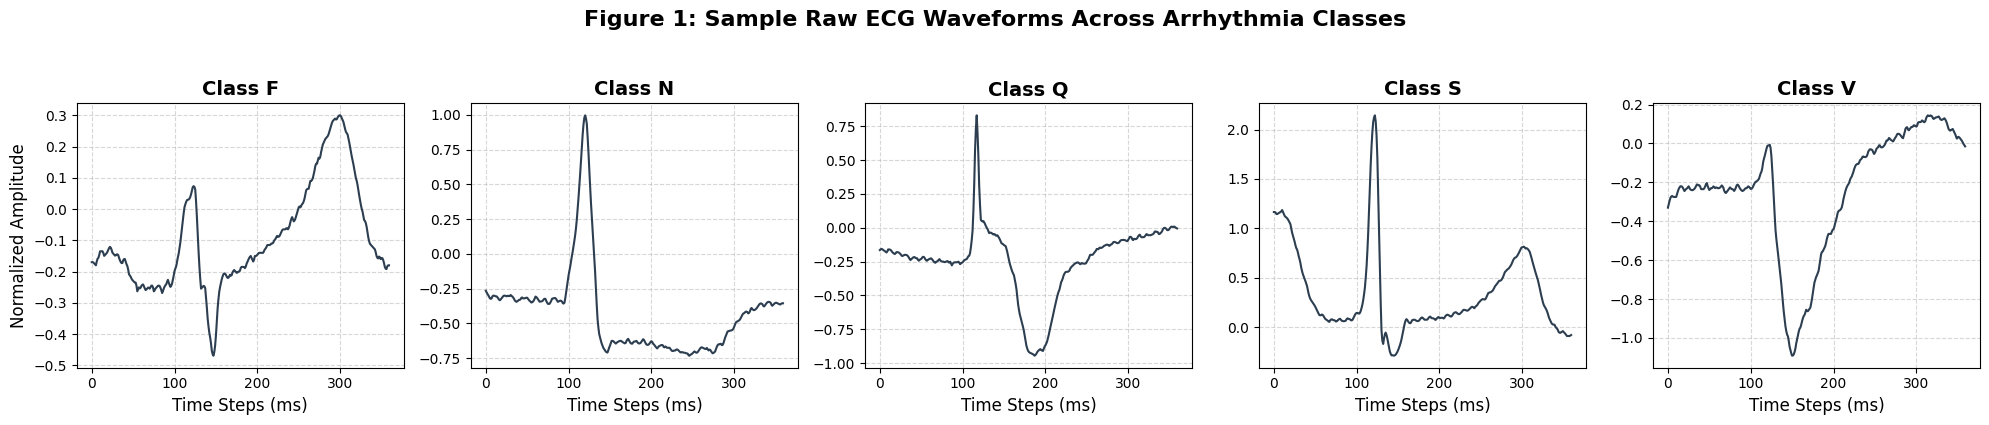

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['F', 'N', 'Q', 'S', 'V']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, cls in enumerate(range(5)):
    idx = np.where(y_test == cls)[0][0]
    sample_signal = X_m1_test[idx]

    axes[i].plot(sample_signal, color='#2c3e50', linewidth=1.5)
    axes[i].set_title(f'Class {classes[i]}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Time Steps (ms)', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Normalized Amplitude', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Figure 1: Sample Raw ECG Waveforms Across Arrhythmia Classes', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()